In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import (pairwise_distances, silhouette_score, silhouette_samples,
                              calinski_harabasz_score, davies_bouldin_score,
                              adjusted_rand_score)

import warnings; warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Ready.")

Ready.


In [2]:
if "google.colab" in sys.modules:
    from google.colab import files
    uploaded = files.upload()
    FILENAME = list(uploaded.keys())[0]
else:
    FILENAME = "ftse250_clustering_ready.csv"
print("Using file:", FILENAME)

Saving ftse250_clustering_ready.csv to ftse250_clustering_ready.csv
Using file: ftse250_clustering_ready.csv


In [3]:
MAX_MISSING_FRAC = 0.10

df = pd.read_csv(FILENAME)
date_cols = [c for c in df.columns if c != "Ticker"]

frac = df[date_cols].isna().sum(axis=1) / len(date_cols)
dropped = df.loc[frac > MAX_MISSING_FRAC, "Ticker"].tolist()
df = df.loc[frac <= MAX_MISSING_FRAC].reset_index(drop=True)

n_filled = int(df[date_cols].isna().sum().sum())
df[date_cols] = df[date_cols].ffill(axis=1).bfill(axis=1)

tickers = df["Ticker"].values
A = df[date_cols].values.astype(float)
dates = pd.to_datetime(date_cols)

print(f"Dropped (>10% missing) : {len(dropped)} {dropped}")
print(f"Single gaps filled     : {n_filled}")
print(f"Stocks retained        : {len(df)}")
print(f"Trading days           : {len(date_cols)}")
print(f"Date range              : {date_cols[0]} to {date_cols[-1]}")
assert df[date_cols].isna().sum().sum() == 0

Dropped (>10% missing) : 0 []
Single gaps filled     : 4
Stocks retained        : 241
Trading days           : 1153
Date range              : 2021-11-30 to 2026-06-29


In [5]:
USE_PCA = True
VARIANCE_TARGET = 0.90

pca = PCA(n_components=VARIANCE_TARGET, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(A)
print(f"PCA: {A.shape[1]} days -> {X_pca.shape[1]} components "
      f"({VARIANCE_TARGET:.0%} of variance)")
print(f"PC1 alone explains {pca.explained_variance_ratio_[0]*100:.1f}% ")

n_samples, n_features = X_pca.shape

D_corr = pairwise_distances(A, metric="correlation")
print(f"\nCorrelation distance matrix: {D_corr.shape}, range "
      f"[{D_corr[D_corr>0].min():.4f}, {D_corr.max():.4f}]")
print("(0 = perfectly positively correlated, 1 = uncorrelated, 2 = perfectly negatively correlated)")

X_ref = X_pca

PCA: 1153 days -> 9 components (90% of variance)
PC1 alone explains 48.0% 

Correlation distance matrix: (241, 241), range [0.0092, 1.9414]
(0 = perfectly positively correlated, 1 = uncorrelated, 2 = perfectly negatively correlated)


In [6]:
def find_knee(y):
    y = np.asarray(y, dtype=float)
    x = np.arange(len(y))
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-12)
    line_y = y_norm[0] + (y_norm[-1] - y_norm[0]) * x_norm
    return int(np.argmax(line_y - y_norm))


def k_distance(k, metric, X=None, Dmat=None):

    if Dmat is not None:
        s = np.sort(Dmat, axis=1)
        return np.sort(s[:, k])
    nbrs = NearestNeighbors(n_neighbors=k + 1, metric=metric).fit(X)
    dist, _ = nbrs.kneighbors(X)
    return np.sort(dist[:, -1])


EPS_SCALES = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.25, 1.5]


MCS_PCA = sorted(set([
    max(2 * n_features, 4),
    max(int(round(np.log(n_samples))), 3),
    n_features + 1,
]))

MCS_CORR = sorted(set([max(int(round(np.log(n_samples))), 3), 4, 5, 8, 10]))

print("PCA-representation MinPts candidates:", MCS_PCA)
print("Correlation-representation MinPts candidates:", MCS_CORR)
print("eps scale factors (applied around each representation's own knee):", EPS_SCALES)

PCA-representation MinPts candidates: [5, 10, 18]
Correlation-representation MinPts candidates: [4, 5, 8, 10]
eps scale factors (applied around each representation's own knee): [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.25, 1.5]


In [7]:
t0 = time.time()
rows = []

for metric in ["euclidean", "manhattan"]:
    for minpts in MCS_PCA:
        kd = k_distance(minpts, metric, X=X_pca)
        knee_eps = kd[find_knee(kd)]
        for scale in EPS_SCALES:
            eps = knee_eps * scale
            labels = DBSCAN(eps=eps, min_samples=minpts, metric=metric).fit_predict(X_pca)
            non_noise = labels[labels != -1]
            n_clusters = len(set(non_noise))
            noise_frac = (labels == -1).mean()
            largest_frac = (pd.Series(non_noise).value_counts().iloc[0] / len(non_noise)
                             if len(non_noise) > 0 else np.nan)
            sil = cal = dav = np.nan
            if n_clusters >= 2 and len(non_noise) >= 10:
                try:
                    sil = silhouette_score(X_pca[labels != -1], non_noise, metric=metric)
                    cal = calinski_harabasz_score(X_ref[labels != -1], labels[labels != -1])
                    dav = davies_bouldin_score(X_ref[labels != -1], labels[labels != -1])
                except Exception:
                    pass
            rows.append(dict(representation=f"pca-{metric}", minpts=minpts, eps=eps,
                              n_clusters=n_clusters, noise_frac=noise_frac,
                              largest_frac=largest_frac, silhouette=sil,
                              calinski=cal, davies=dav))


for minpts in MCS_CORR:
    kd = k_distance(minpts, "precomputed", Dmat=D_corr)
    knee_eps = kd[find_knee(kd)]
    for scale in EPS_SCALES:
        eps = knee_eps * scale
        labels = DBSCAN(eps=eps, min_samples=minpts, metric="precomputed").fit_predict(D_corr)
        non_noise = labels[labels != -1]
        n_clusters = len(set(non_noise))
        noise_frac = (labels == -1).mean()
        largest_frac = (pd.Series(non_noise).value_counts().iloc[0] / len(non_noise)
                         if len(non_noise) > 0 else np.nan)
        sil = cal = dav = np.nan
        if n_clusters >= 2 and len(non_noise) >= 10:
            try:
                sub = D_corr[np.ix_(labels != -1, labels != -1)]
                sil = silhouette_score(sub, non_noise, metric="precomputed")
                cal = calinski_harabasz_score(X_ref[labels != -1], labels[labels != -1])
                dav = davies_bouldin_score(X_ref[labels != -1], labels[labels != -1])
            except Exception:
                pass
        rows.append(dict(representation="raw-correlation", minpts=minpts, eps=eps,
                          n_clusters=n_clusters, noise_frac=noise_frac,
                          largest_frac=largest_frac, silhouette=sil,
                          calinski=cal, davies=dav))

grid = pd.DataFrame(rows)
print(f"Grid search over {len(grid)} combinations across 3 representations in {time.time()-t0:.1f}s")
print(grid.groupby("representation").size().rename("combinations tried"))

Grid search over 90 combinations across 3 representations in 0.5s
representation
pca-euclidean      27
pca-manhattan      27
raw-correlation    36
Name: combinations tried, dtype: int64


In [8]:
NOISE_CEILING = 0.90
GIANT_CLUSTER_CEILING = 0.90
MIN_CLUSTERS = 2

valid = grid[
    (grid["n_clusters"] >= MIN_CLUSTERS) &
    (grid["noise_frac"] <= NOISE_CEILING) &
    (grid["largest_frac"] <= GIANT_CLUSTER_CEILING) &
    grid["silhouette"].notna()
]
print(f"Valid (non-degenerate) combinations: {len(valid)} / {len(grid)}")
print(valid.groupby("representation").size().rename("valid combinations"))

pool = valid if len(valid) > 0 else grid
if len(valid) == 0:
    print("\nWARNING: no combination avoided the degenerate cases. Falling back to "
          "the best composite index across ALL combinations -- inspect carefully.")

def norm01(s):
    s = s.astype(float)
    if s.max() == s.min():
        return s * 0 + 0.5
    return (s - s.min()) / (s.max() - s.min())


pool = pool.copy()
pool["sil_n"] = norm01(pool["silhouette"])
pool["cal_n"] = norm01(pool["calinski"])
pool["dav_n"] = norm01(-pool["davies"])
pool["composite"] = pool[["sil_n", "cal_n", "dav_n"]].mean(axis=1)

display(pool.sort_values("composite", ascending=False)
        .head(10)[["representation", "minpts", "eps", "n_clusters", "noise_frac",
                    "largest_frac", "silhouette", "composite"]].round(4))

Valid (non-degenerate) combinations: 22 / 90
representation
pca-euclidean      8
pca-manhattan      7
raw-correlation    7
Name: valid combinations, dtype: int64


,representation,minpts,eps,n_clusters,noise_frac,largest_frac,silhouette,composite
63,raw-correlation,5,0.1258,2,0.4647,0.6512,0.8392,0.9214
72,raw-correlation,8,0.1369,2,0.4440,0.6418,0.8284,0.8947
81,raw-correlation,10,0.1504,2,0.4315,0.6496,0.8211,0.8704
1,pca-euclidean,5,13.1843,2,0.4689,0.6562,0.6622,0.8346
10,pca-euclidean,10,15.0522,2,0.4232,0.6475,0.6377,0.7668
19,pca-euclidean,18,15.9577,2,0.4689,0.7031,0.6520,0.7618
73,raw-correlation,8,0.1643,2,0.3817,0.6242,0.7666,0.7157
64,raw-correlation,5,0.1510,2,0.3942,0.6233,0.7641,0.7109
46,pca-manhattan,18,36.8939,2,0.4481,0.6767,0.5248,0.7103
82,raw-correlation,10,0.1805,2,0.3651,0.6078,0.7561,0.6953


In [9]:
# Subsampling stability (Ben-Hur, Elisseeff & Guyon, 2002), kept in sync with
# the K-Means / K-Medoids+DTW notebooks -- same B, frac and floor. IMPORTANT
# DBSCAN-specific fix: -1 is a real DBSCAN label (noise), so it can't double
# as the "this point wasn't sampled this round" sentinel the other notebooks
# use. This version uses -2 for that instead, so noise points are compared
# correctly instead of being silently dropped.

def subsample_stability(representation, eps, minpts, metric, B=100, frac=0.8,
                        min_overlap=10, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(tickers)
    m = int(frac * n)

    labels_mat = np.full((B, n), -2, dtype=int)  # -2 = not sampled this round
    for b in range(B):
        idx = rng.choice(n, m, replace=False)
        if representation == "raw-correlation":
            sub = D_corr[np.ix_(idx, idx)]
            lab = DBSCAN(eps=eps, min_samples=minpts, metric="precomputed").fit_predict(sub)
        else:
            lab = DBSCAN(eps=eps, min_samples=minpts, metric=metric).fit_predict(X_pca[idx])
        labels_mat[b, idx] = lab

    aris = []
    for i in range(B):
        for j in range(i + 1, B):
            common = (labels_mat[i] != -2) & (labels_mat[j] != -2)
            if common.sum() < min_overlap:
                continue
            aris.append(adjusted_rand_score(labels_mat[i, common], labels_mat[j, common]))

    if not aris:
        return np.nan, np.nan
    return float(np.mean(aris)), float(np.min(aris))


print("Function defined.")

Function defined.


In [10]:
# Stability now gates the choice instead of only being reported afterward:
# take the top-N composite candidates, compute their subsampling stability,
# and pick the best-composite one that clears the floor.
TOP_N_FOR_STABILITY = 10
N_SUBSAMPLES = 100
SUBSAMPLE_FRAC = 0.8
STABILITY_FLOOR = 0.65

t0 = time.time()
ranked = pool.sort_values("composite", ascending=False).head(TOP_N_FOR_STABILITY).copy()

stabs = []
for _, row in ranked.iterrows():
    metric_for_stab = (None if row["representation"] == "raw-correlation"
                        else row["representation"].split("-")[1])
    stab, stab_min = subsample_stability(row["representation"], row["eps"], int(row["minpts"]),
                                          metric_for_stab, B=N_SUBSAMPLES, frac=SUBSAMPLE_FRAC)
    stabs.append((stab, stab_min))
ranked["stability"], ranked["stability_min"] = zip(*stabs)
ranked["stable"] = ranked["stability"] >= STABILITY_FLOOR

print(f"Stability computed for top {TOP_N_FOR_STABILITY} candidates in {time.time()-t0:.0f}s\n")
display(ranked[["representation", "minpts", "eps", "n_clusters", "composite",
                "stability", "stability_min", "stable"]].round(4))

admissible = ranked[ranked["stable"]]
if len(admissible) == 0:
    print(f"\nWARNING: none of the top {TOP_N_FOR_STABILITY} composite candidates reach the "
          f"stability floor of {STABILITY_FLOOR}.")
    print("Falling back to the single best composite-score candidate -- treat as tentative.")
    chosen = ranked.sort_values("composite", ascending=False).iloc[0]
else:
    chosen = admissible.sort_values("composite", ascending=False).iloc[0]

REPRESENTATION = chosen["representation"]
MINPTS = int(chosen["minpts"])
EPS = float(chosen["eps"])

print(f"\nBest composite alone would pick : {ranked.iloc[0]['representation']}, "
      f"MinPts={int(ranked.iloc[0]['minpts'])}, eps={ranked.iloc[0]['eps']:.4f}")
print(f"Stability-gated choice           : {REPRESENTATION}, MinPts={MINPTS}, eps={EPS:.4f}")
print(f"Stability of chosen combination  : {chosen['stability']:.4f}  "
      f"({'PASS' if chosen['stable'] else 'FAIL (fallback)'})")

Stability computed for top 10 candidates in 61s



,representation,minpts,eps,n_clusters,composite,stability,stability_min,stable
63,raw-correlation,5,0.1258,2,0.9214,0.9488,0.8496,True
72,raw-correlation,8,0.1369,2,0.8947,0.9267,0.7733,True
81,raw-correlation,10,0.1504,2,0.8704,0.9326,0.7640,True
1,pca-euclidean,5,13.1843,2,0.8346,0.9436,0.7479,True
10,pca-euclidean,10,15.0522,2,0.7668,0.8908,0.6979,True
19,pca-euclidean,18,15.9577,2,0.7618,0.8321,0.5773,True
73,raw-correlation,8,0.1643,2,0.7157,0.9218,0.7791,True
64,raw-correlation,5,0.1510,2,0.7109,0.9218,0.7676,True
46,pca-manhattan,18,36.8939,2,0.7103,0.8679,0.6234,True
82,raw-correlation,10,0.1805,2,0.6953,0.9436,0.7607,True



Best composite alone would pick : raw-correlation, MinPts=5, eps=0.1258
Stability-gated choice           : raw-correlation, MinPts=5, eps=0.1258
Stability of chosen combination  : 0.9488  (PASS)


In [11]:
if REPRESENTATION == "raw-correlation":
    METRIC = "precomputed"
    labels = DBSCAN(eps=EPS, min_samples=MINPTS, metric="precomputed").fit_predict(D_corr)
else:
    METRIC = REPRESENTATION.split("-")[1]  # "euclidean" or "manhattan"
    labels = DBSCAN(eps=EPS, min_samples=MINPTS, metric=METRIC).fit_predict(X_pca)

nonnoise_mask = labels != -1
n_noise = int((labels == -1).sum())
noise_frac = n_noise / len(labels)
n_clusters = len(set(labels[nonnoise_mask]))
sizes = pd.Series(labels[nonnoise_mask]).value_counts().sort_index()
largest_frac = sizes.max() / sizes.sum()

if REPRESENTATION == "raw-correlation":
    sub = D_corr[np.ix_(nonnoise_mask, nonnoise_mask)]
    sil = silhouette_score(sub, labels[nonnoise_mask], metric="precomputed")
else:
    sil = silhouette_score(X_pca[nonnoise_mask], labels[nonnoise_mask], metric=METRIC)

print("=" * 50)
print(f"  DATASET        : {FILENAME}")
print(f"  Stocks         : {len(tickers)}")
print(f"  Representation : {REPRESENTATION}")
print(f"  MinPts         : {MINPTS}")
print(f"  eps            : {EPS:.4f}")
print("-" * 50)
print(f"  Clusters found : {n_clusters}")
print(f"  Cluster sizes  : {sizes.to_dict()}")
print(f"  Outliers       : {n_noise} ({noise_frac:.1%})")
print(f"  Largest cluster share of non-noise points: {largest_frac:.1%}")
print(f"  Silhouette (metric-consistent, non-noise points): {sil:.4f}")
print(f"  Stability      : {chosen['stability']:.4f}  (worst pair {chosen['stability_min']:.3f})")
print(f"  Stability floor: {STABILITY_FLOOR}  ->  {'PASS' if chosen['stable'] else 'FAIL'}")
print("-" * 50)

# Ticker -> cluster table for downstream use (-1 = noise/unclustered)
assignments = pd.DataFrame({"ticker": list(tickers), "cluster": labels})

  DATASET        : ftse250_clustering_ready.csv
  Stocks         : 241
  Representation : raw-correlation
  MinPts         : 5
  eps            : 0.1258
--------------------------------------------------
  Clusters found : 2
  Cluster sizes  : {0: 45, 1: 84}
  Outliers       : 112 (46.5%)
  Largest cluster share of non-noise points: 65.1%
  Silhouette (metric-consistent, non-noise points): 0.8392
  Stability      : 0.9488  (worst pair 0.850)
  Stability floor: 0.65  ->  PASS
--------------------------------------------------


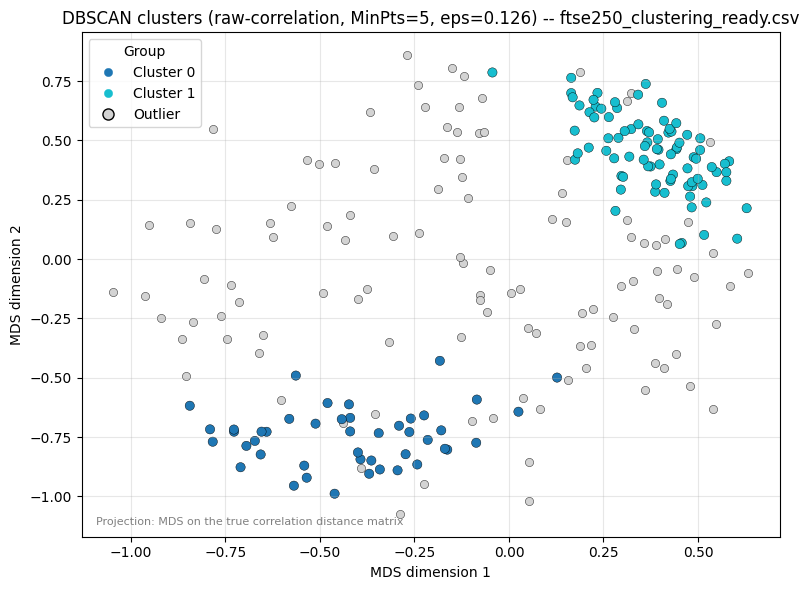

In [12]:
if REPRESENTATION == "raw-correlation":
    vis_coords = MDS(n_components=2, dissimilarity="precomputed", random_state=RANDOM_STATE,
                      normalized_stress=False, n_init=4).fit_transform(D_corr)
    xlabel, ylabel = "MDS dimension 1", "MDS dimension 2"
    vis_note = "MDS on the true correlation distance matrix"
else:
    vis2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_pca)
    vis_coords = vis2.transform(X_pca)
    xlabel = f"PC1 ({vis2.explained_variance_ratio_[0]*100:.1f}%)"
    ylabel = f"PC2 ({vis2.explained_variance_ratio_[1]*100:.1f}%)"
    vis_note = "PCA (2 components)"

fig, ax = plt.subplots(figsize=(8, 6))
out_mask = labels == -1
ax.scatter(vis_coords[out_mask, 0], vis_coords[out_mask, 1], c="lightgray", s=35,
           edgecolor="k", linewidth=0.3, label="Outlier (noise)")
sc = ax.scatter(vis_coords[~out_mask, 0], vis_coords[~out_mask, 1], c=labels[~out_mask],
                 cmap="tab10", s=45, edgecolor="k", linewidth=0.3)
ax.set_title(f"DBSCAN clusters ({REPRESENTATION}, MinPts={MINPTS}, eps={EPS:.3f}) -- {FILENAME}")
ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
handles, _ = sc.legend_elements()
labels_leg = [f"Cluster {c}" for c in sorted(set(labels[~out_mask]))]
ax.legend(handles + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
                                  markeredgecolor='k', markersize=8)],
          labels_leg + ["Outlier"], title="Group", loc="best")
ax.text(0.02, 0.02, f"Projection: {vis_note}", transform=ax.transAxes, fontsize=8,
        color="gray", va="bottom")
plt.tight_layout(); plt.show()

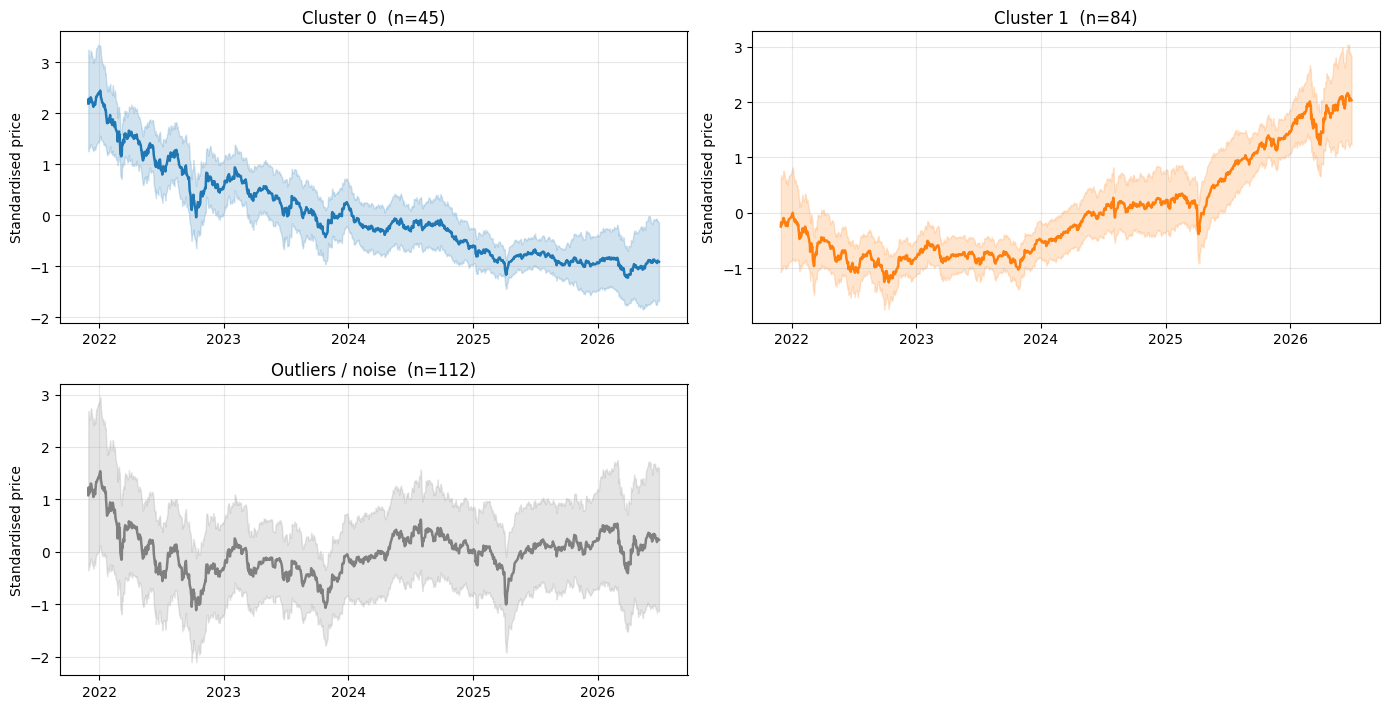

In [13]:
cluster_ids = sorted(set(labels[labels != -1]))
n_panels = len(cluster_ids) + (1 if n_noise > 0 else 0)
n_cols = 2
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows), squeeze=False)

panel = 0
for c in cluster_ids:
    ax = axes[panel // n_cols][panel % n_cols]
    mem = A[labels == c]
    mu, sd = mem.mean(axis=0), mem.std(axis=0)
    ax.plot(dates, mu, color=f"C{c}", lw=1.8)
    ax.fill_between(dates, mu - sd, mu + sd, color=f"C{c}", alpha=0.2)
    ax.set_title(f"Cluster {c}  (n={len(mem)})")
    ax.set_ylabel("Standardised price")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    panel += 1

if n_noise > 0:
    ax = axes[panel // n_cols][panel % n_cols]
    mem = A[labels == -1]
    mu, sd = mem.mean(axis=0), mem.std(axis=0)
    ax.plot(dates, mu, color="gray", lw=1.8)
    ax.fill_between(dates, mu - sd, mu + sd, color="gray", alpha=0.2)
    ax.set_title(f"Outliers / noise  (n={len(mem)})")
    ax.set_ylabel("Standardised price")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    panel += 1

for p in range(panel, n_rows * n_cols):
    axes[p // n_cols][p % n_cols].axis("off")
plt.tight_layout(); plt.show()

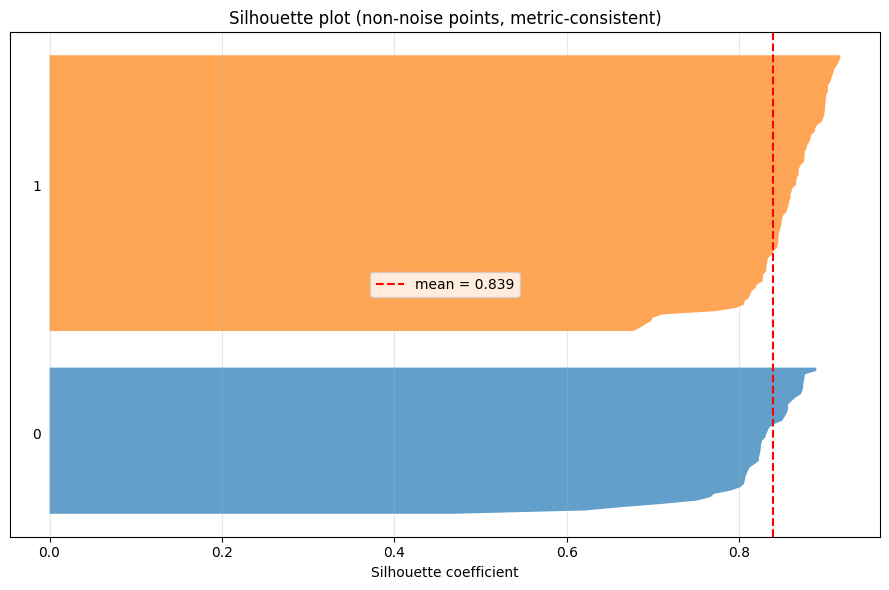

In [14]:
if REPRESENTATION == "raw-correlation":
    sv = silhouette_samples(D_corr[np.ix_(nonnoise_mask, nonnoise_mask)],
                             labels[nonnoise_mask], metric="precomputed")
else:
    sv = silhouette_samples(X_pca[nonnoise_mask], labels[nonnoise_mask], metric=METRIC)

fig, ax = plt.subplots(figsize=(9, 6))
y = 10
for c in cluster_ids:
    v = np.sort(sv[labels[nonnoise_mask] == c])
    ax.fill_betweenx(np.arange(y, y + len(v)), 0, v, facecolor=f"C{c}", alpha=0.7)
    ax.text(-0.02, y + 0.5 * len(v), str(c))
    y += len(v) + 10
ax.axvline(sv.mean(), color="red", ls="--", label=f"mean = {sv.mean():.3f}")
ax.set_title("Silhouette plot (non-noise points, metric-consistent)")
ax.set_xlabel("Silhouette coefficient")
ax.set_yticks([]); ax.legend(); plt.tight_layout(); plt.show()

In [15]:
import textwrap
for c in cluster_ids:
    mem = sorted(tickers[labels == c])
    print(f"Cluster {c} (n={len(mem)}):")
    print(textwrap.fill(", ".join(mem), width=95))
    print()

if n_noise > 0:
    outliers = sorted(tickers[labels == -1])
    print(f"Outliers / noise (n={len(outliers)}):")
    print(textwrap.fill(", ".join(outliers), width=95))

Cluster 0 (n=45):
AML.L, BME.L, BSIF.L, BYG.L, CBG.L, CWR.L, DLN.L, DOCS.L, FGEN.L, GCP.L, GPE.L, GRI.L, HAS.L,
HICL.L, INPP.L, IPO.L, KNOS.L, MNDI.L, OCDO.L, ONT.L, PAGE.L, PETS.L, PHP.L, PNN.L, RCP.L,
RS1.L, SAFE.L, SEIT.L, SEQI.L, SMWH.L, SUPR.L, SYNC.L, TATE.L, THG.L, TPK.L, TRIG.L, TRY.L,
UKW.L, UTG.L, VCT.L, WIZZ.L, WKP.L, WOSG.L, WPP.L, XPP.L

Cluster 1 (n=84):
AAS.L, AEP.L, AGT.L, AIE.L, AJB.L, ASL.L, ATR.L, ATT.L, ATYM.L, AVON.L, BAG.L, BBY.L, BNKR.L,
BPCR.L, BUT.L, CHG.L, CLDN.L, COST.L, CSN.L, CTY.L, CURY.L, CWK.L, EDIN.L, ELM.L, ESCT.L,
FAN.L, FCH.L, FEML.L, FEV.L, FSV.L, GDWN.L, GFRD.L, GNC.L, GSCT.L, HANA.L, HILS.L, HOC.L,
HRI.L, HTWS.L, HVPE.L, IAD.L, ICGT.L, IPF.L, JAM.L, JCH.L, JEDT.L, JEGI.L, JEMI.L, JFJ.L,
JGGI.L, JMGI.L, JTC.L, KIE.L, KLR.L, LWDB.L, MGNS.L, MNKS.L, MRC.L, MTO.L, MYI.L, OCI.L, PAF.L,
PAG.L, PFD.L, PHI.L, PIN.L, PLUS.L, PNL.L, PPET.L, QLT.L, RTW.L, SAGA.L, SDP.L, SNR.L, SOI.L,
SRP.L, TBCG.L, TCAP.L, TEM.L, TMPL.L, UEM.L, USA.L, WIX.L, XPS.L

Outliers 

In [16]:
t_idx = np.arange(A.shape[1])
trend = np.array([np.polyfit(t_idx, row, 1)[0] for row in A])
volatility = np.diff(A, axis=1).std(axis=1)

summary_df = pd.DataFrame({"Ticker": tickers, "Cluster": labels,
                            "Volatility": volatility, "Trend": trend})
cluster_summary = summary_df.groupby("Cluster").agg(
    n_stocks=("Ticker", "count"),
    avg_volatility=("Volatility", "mean"),
    avg_trend=("Trend", "mean"),
).round(4)
print("Per-cluster characteristics (-1 = noise/unclustered):")
display(cluster_summary)

Per-cluster characteristics (-1 = noise/unclustered):


,n_stocks,avg_volatility,avg_trend
Cluster,,,
-1,112,0.1293,0.0001
0,45,0.0811,-0.0024
1,84,0.0771,0.0023


In [17]:
trend_sign = (trend > 0).astype(int)
ari_trend = adjusted_rand_score(labels, trend_sign)
print(f"ARI between DBSCAN clusters (incl. noise as its own group) and sign-of-trend: {ari_trend:.3f}")
print()
if ari_trend > 0.7:
    print("=> The clustering is largely a restatement of trend direction.")
elif ari_trend > 0.3:
    print("=> Trend explains part of the clustering, but not all of it.")
else:
    print("=> The clustering is capturing something beyond trend direction.")

print(f"\nStocks trending up: {trend_sign.sum()} / down: {(1-trend_sign).sum()}")

ARI between DBSCAN clusters (incl. noise as its own group) and sign-of-trend: 0.290

=> The clustering is capturing something beyond trend direction.

Stocks trending up: 139 / down: 102
